In [1]:
import re
import random
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

In [2]:
seed = 42

DATA_FILE = Path("data") / "The_Fellowship_Of_The_Ring.txt"
WEIGHTS_DIR = Path("weights")
WEIGHTS_DIR.mkdir(exist_ok=True)

SG_WEIGHTS = WEIGHTS_DIR / "skipgram_weights.pt"
CBOW_WEIGHTS = WEIGHTS_DIR / "cbow_weights.pt"

WINDOW = 3
WINDOW_CBOW = 2
MAX_VOCAB = 200000
MIN_COUNT = 2
EMBEDDING_DIM = 200
BATCH_SIZE = 1024
EPOCHS_SG = 10
EPOCHS_CBOW = 10
K_NEG = 5
LR = 2e-3

SG_MODE = True
CBOW_MODE = True

SEED / DEVICE

Загрузка исходного теста

In [3]:
def seed_all(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_all(seed)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(device)

cuda


# Задание 2
сегментируем текст на фрагменты.

In [4]:
def read_all_txt(file_path: Path) -> str:
    text = file_path.read_text(encoding="utf-8", errors="ignore").lower()
    return text


text = read_all_txt(DATA_FILE)

print("Размер текста в символах:", len(text))
print("\nПервые 500 символов:\n")
print(text[:500])

print("Размер текста в символах:", len(text))
print("Первые 500 символов:\n")
print(text[:500])


WORD = re.compile(r"[a-z]+(?:'[a-z]+)?")

def split_sentence(text: str) -> list[str]:
    text = text.replace("\r", "\n")
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)

    if any(ch in text for ch in [".", "?", "!"]):
        parts = re.split(r"[.?!]+", text)
        parts = [p.strip() for p in parts if p.strip()]
        if parts:
            return parts

    lines = []
    for line in text.split("\n"):
        s = line.strip()
        if s:
            lines.append(s)

    return lines

def tokenize(string: str) -> list[str]:
    return WORD.findall(string)

sentences = split_sentence(text)

print("Количество предложений:", len(sentences))
print("\nПервые 5 предложений:\n")
for i, s in enumerate(sentences[:5], 1):
    print(f"{i}. {s[:200]}")


tokenized_sentences = [tokenize(sentence) for sentence in sentences]
tokenized_sentences = [sentence for sentence in tokenized_sentences if len(sentence) >= 2]

total_tokens = sum(len(sentence) for sentence in tokenized_sentences)

print("Количество предложений после фильтрации:", len(tokenized_sentences))
print("Количество токенов:", total_tokens)
print("\nПервые 3 токенизированных предложения:\n")
for i, s in enumerate(tokenized_sentences[:3], 1):
    print(f"{i}.", s[:25])

Размер текста в символах: 952801

Первые 500 символов:

this tale grew in the telling until it became a history of the great war of
the ring and included many glimpses of the yet more ancient history that
preceded it it was begun soon after the hobbit was written and before
its publication in 1937 but i did not go on with this sequel for i wished
first to complete and set in order the mythology and legends of the elder days
which had then been taking shape for some years i desired to do this for my own
satisfaction and i had little hope that other pe
Размер текста в символах: 952801
Первые 500 символов:

this tale grew in the telling until it became a history of the great war of
the ring and included many glimpses of the yet more ancient history that
preceded it it was begun soon after the hobbit was written and before
its publication in 1937 but i did not go on with this sequel for i wished
first to complete and set in order the mythology and legends of the elder days
which had then b

построение словаря и subsampling

In [5]:
##%%
def build_vocab(tokenized_sentences, max_vocab=MAX_VOCAB, min_count=MIN_COUNT):
    counter = Counter(token for sentence in tokenized_sentences for token in sentence)
    items = [(word, count) for word, count in counter.items() if count >= min_count]
    items.sort(key=lambda x: x[1], reverse=True)

    vocab = ["<UNK>"] + [word for word, _ in items[:max(0, max_vocab - 1)]]
    word2id = {word: index for index, word in enumerate(vocab)}
    id2word = {index: word for index, word in enumerate(vocab)}

    return vocab, word2id, id2word, counter

vocab, word2id, id2word, counter = build_vocab(
    tokenized_sentences,
    max_vocab=MAX_VOCAB,
    min_count=MIN_COUNT
)

print("Уникальных слов всего:", len(counter))
print("Размер словаря:", len(vocab))
print("Топ-10 слов:", counter.most_common(10))

unk_id = word2id["<UNK>"]

encoded_sentences = []
for sentence in tokenized_sentences:
    encoded_sentence = [word2id.get(word, unk_id) for word in sentence]
    encoded_sentences.append(encoded_sentence)

total_encoded_tokens = sum(len(sentence) for sentence in encoded_sentences)
unk_tokens = sum(1 for sentence in encoded_sentences for token_id in sentence if token_id == unk_id)

print("Всего закодированных токенов:", total_encoded_tokens)
print("UNK токенов:", unk_tokens)
print("Доля UNK:", unk_tokens / total_encoded_tokens if total_encoded_tokens > 0 else 0.0)


def subsample(encoded_sentences, t=1e-3):
    counter_local = Counter(word for s in encoded_sentences for word in s)
    total = sum(counter_local.values())
    freqs = {w: c / total for w, c in counter_local.items()}

    out = []
    for sentence in encoded_sentences:
        ns = []
        for word in sentence:
            freq = freqs[word]
            p_drop = max(0, 1 - (t / freq) ** 0.5)
            if random.random() > p_drop:
                ns.append(word)
        if len(ns) > 2:
            out.append(ns)
    return out

tokens_before = sum(len(s) for s in encoded_sentences)
encoded_sentences_subsampled = subsample(encoded_sentences, t=1e-4)
tokens_after = sum(len(s) for s in encoded_sentences_subsampled)

print("Токенов до subsampling:", tokens_before)
print("Токенов после subsampling:", tokens_after)
print("Осталось:", tokens_after / tokens_before if tokens_before > 0 else 0.0)
print("Предложений после subsampling:", len(encoded_sentences_subsampled))

Уникальных слов всего: 8678
Размер словаря: 5327
Топ-10 слов: [('the', 11614), ('and', 7501), ('of', 5025), ('to', 3910), ('a', 3691), ('he', 2992), ('in', 2978), ('it', 2723), ('i', 2723), ('that', 2489)]
Всего закодированных токенов: 187244
UNK токенов: 3352
Доля UNK: 0.01790177522377219
Токенов до subsampling: 187244
Токенов после subsampling: 61371
Осталось: 0.32775950097199374
Предложений после subsampling: 12080


Skip-gram dataset

In [6]:
def make_skipgram_pairs(encoded_sentences, window=WINDOW):
    pairs = []
    for sentence in encoded_sentences:
        length = len(sentence)
        for index, center in enumerate(sentence):
            left = max(0, index - window)
            right = min(length, index + window + 1)

            for j in range(left, right):
                if j != index:
                    pairs.append((center, sentence[j]))

    return np.asarray(pairs, dtype=np.int64)

class SkipGramPairDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = torch.from_numpy(pairs).long()

    def __len__(self):
        return self.pairs.shape[0]

    def __getitem__(self, index):
        return self.pairs[index, 0], self.pairs[index, 1]

skipgram_pairs = make_skipgram_pairs(encoded_sentences_subsampled, window=WINDOW)

print("Количество skip-gram пар:", len(skipgram_pairs))
print("Форма массива:", skipgram_pairs.shape)
print("Первые 10 пар:\n", skipgram_pairs[:10])


skipgram_dataset = SkipGramPairDataset(skipgram_pairs)
skipgram_dataloader = DataLoader(
    skipgram_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
    num_workers=0
)

print("Размер skipgram_dataset:", len(skipgram_dataset))
print("Количество batch'ей:", len(skipgram_dataloader))

for center_ids, positive_ids in skipgram_dataloader:
    print("center_ids shape:", center_ids.shape)
    print("positive_ids shape:", positive_ids.shape)
    print("Первые 10 center_ids:", center_ids[:10].tolist())
    print("Первые 10 positive_ids:", positive_ids[:10].tolist())
    break


vocab_size = len(vocab)

id_counts = torch.zeros(vocab_size, dtype=torch.float32)
for sentence in encoded_sentences:
    for token_id in sentence:
        id_counts[token_id] += 1

negative_weights = id_counts.pow(0.75)
negative_weights[unk_id] = 0.0
negative_probs = negative_weights / negative_weights.sum()
negative_probs_device = negative_probs.to(device)

print("V =", vocab_size)
print("total_tokens =", int(id_counts.sum().item()))
print("sum(negative_probs) =", float(negative_probs.sum().item()))
print("negative_probs_device =", negative_probs_device.device)

Количество skip-gram пар: 223266
Форма массива: (223266, 2)
Первые 10 пар:
 [[1373  197]
 [1373  566]
 [ 197 1373]
 [ 197  566]
 [ 566 1373]
 [ 566  197]
 [2844   69]
 [2844 2184]
 [2844  107]
 [  69 2844]]
Размер skipgram_dataset: 223266
Количество batch'ей: 219
center_ids shape: torch.Size([1024])
positive_ids shape: torch.Size([1024])
Первые 10 center_ids: [1268, 5267, 24, 15, 408, 2741, 81, 4263, 3033, 1355]
Первые 10 positive_ids: [887, 533, 348, 434, 337, 1967, 1006, 1479, 1162, 439]
V = 5327
total_tokens = 187244
sum(negative_probs) = 0.9999998807907104
negative_probs_device = cuda:0


CBOW dataset

Подготовка данных для обучения Skip-gram

In [7]:
##%%
class CBOWDataset(Dataset):
    def __init__(self, sentences_as_ids, window_size=2):
        self.sentences_as_ids = sentences_as_ids
        self.window_size = window_size
        self.samples_index = []

        for sentence_index, sentence_ids in enumerate(sentences_as_ids):
            min_length = 2 * window_size + 1
            if len(sentence_ids) < min_length:
                continue

            for target_position in range(window_size, len(sentence_ids) - window_size):
                self.samples_index.append((sentence_index, target_position))

    def __len__(self):
        return len(self.samples_index)

    def __getitem__(self, sample_index):
        sentence_index, target_position = self.samples_index[sample_index]
        sentence_ids = self.sentences_as_ids[sentence_index]
        window_size = self.window_size

        left_context = sentence_ids[target_position - window_size:target_position]
        right_context = sentence_ids[target_position + 1:target_position + window_size + 1]

        context_ids = left_context + right_context
        target_id = sentence_ids[target_position]

        return (
            torch.tensor(context_ids, dtype=torch.long),
            torch.tensor(target_id, dtype=torch.long)
        )

min_cbow_length = 2 * WINDOW_CBOW + 1
cbow_sentences = [sentence for sentence in encoded_sentences if len(sentence) >= min_cbow_length]

cbow_dataset = CBOWDataset(cbow_sentences, window_size=WINDOW_CBOW)
cbow_dataloader = DataLoader(
    cbow_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
    num_workers=0
)

print("WINDOW_CBOW =", WINDOW_CBOW)
print("Минимальная длина предложения:", min_cbow_length)
print("Предложений для CBOW:", len(cbow_sentences))
print("CBOW примеров:", len(cbow_dataset))
print("CBOW batch'ей:", len(cbow_dataloader))

for context_ids, target_ids in cbow_dataloader:
    print("context_ids shape:", context_ids.shape)
    print("target_ids shape:", target_ids.shape)
    print("Первый context:", context_ids[0].tolist())
    print("Первый target:", int(target_ids[0]))
    break

WINDOW_CBOW = 2
Минимальная длина предложения: 5
Предложений для CBOW: 13665
CBOW примеров: 130577
CBOW batch'ей: 128
context_ids shape: torch.Size([1024, 4])
target_ids shape: torch.Size([1024])
Первый context: [504, 25, 217, 166]
Первый target: 16


Модели

In [8]:
class SkipGramNegSampling(nn.Module):
    def __init__(self, vocab_size: int, emb_dim: int):
        super().__init__()

        self.in_embed = nn.Embedding(vocab_size, emb_dim)
        self.out_embed = nn.Embedding(vocab_size, emb_dim)

        nn.init.uniform_(self.in_embed.weight, -0.5 / emb_dim, 0.5 / emb_dim)
        nn.init.zeros_(self.out_embed.weight)

    def forward(self, center_ids, pos_ids, neg_ids):
        center_vectors = self.in_embed(center_ids)
        positive_vectors = self.out_embed(pos_ids)
        negative_vectors = self.out_embed(neg_ids)

        positive_score = torch.sum(center_vectors * positive_vectors, dim=1)
        positive_loss = F.logsigmoid(positive_score)

        negative_score = torch.bmm(negative_vectors, center_vectors.unsqueeze(2)).squeeze(2)
        negative_loss = F.logsigmoid(-negative_score).sum(dim=1)

        return -(positive_loss + negative_loss).mean()


class CBOW(nn.Module):
    def __init__(self, vocab_size: int, embedding_dim: int):
        super().__init__()

        self.word_embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.output_layer = nn.Linear(embedding_dim, vocab_size)

    def forward(self, context_word_ids):
        context_embeddings = self.word_embeddings(context_word_ids)
        context_mean_vector = context_embeddings.mean(dim=1)
        logits = self.output_layer(context_mean_vector)
        return logits

# Сохранение и загрузка весов

In [9]:
##%%
def save_skipgram(model, path, vocab, word2id, id2word, vocab_size, embedding_dim):
    torch.save({
        "vocab_size": vocab_size,
        "embedding_dim": embedding_dim,
        "state_dict": model.state_dict(),
        "vocab": vocab,
        "word2id": word2id,
        "id2word": id2word
    }, path)

def load_skipgram(path, device):
    checkpoint = torch.load(path, map_location=device)

    model = SkipGramNegSampling(
        checkpoint["vocab_size"],
        checkpoint["embedding_dim"]
    ).to(device)

    model.load_state_dict(checkpoint["state_dict"])
    model.eval()

    return model, checkpoint["vocab"], checkpoint["word2id"], checkpoint["id2word"]

def save_cbow(model, path, vocab, word2id, id2word, vocab_size, embedding_dim):
    torch.save({
        "vocab_size": vocab_size,
        "embedding_dim": embedding_dim,
        "state_dict": model.state_dict(),
        "vocab": vocab,
        "word2id": word2id,
        "id2word": id2word
    }, path)

def load_cbow(path, device):
    checkpoint = torch.load(path, map_location=device)

    model = CBOW(
        checkpoint["vocab_size"],
        checkpoint["embedding_dim"]
    ).to(device)

    model.load_state_dict(checkpoint["state_dict"])
    model.eval()

    return model, checkpoint["vocab"], checkpoint["word2id"], checkpoint["id2word"]

print("SG_WEIGHTS =", SG_WEIGHTS)
print("CBOW_WEIGHTS =", CBOW_WEIGHTS)

SG_WEIGHTS = weights/skipgram_weights.pt
CBOW_WEIGHTS = weights/cbow_weights.pt


In [10]:
def save_skipgram(model, path, vocab, word2id, id2word, vocab_size, embedding_dim):
    torch.save({
        "vocab_size": vocab_size,
        "embedding_dim": embedding_dim,
        "state_dict": model.state_dict(),
        "vocab": vocab,
        "word2id": word2id,
        "id2word": id2word
    }, path)

def load_skipgram(path, device):
    checkpoint = torch.load(path, map_location=device)

    model = SkipGramNegSampling(
        checkpoint["vocab_size"],
        checkpoint["embedding_dim"]
    ).to(device)

    model.load_state_dict(checkpoint["state_dict"])
    model.eval()

    return model, checkpoint["vocab"], checkpoint["word2id"], checkpoint["id2word"]

def save_cbow(model, path, vocab, word2id, id2word, vocab_size, embedding_dim):
    torch.save({
        "vocab_size": vocab_size,
        "embedding_dim": embedding_dim,
        "state_dict": model.state_dict(),
        "vocab": vocab,
        "word2id": word2id,
        "id2word": id2word
    }, path)

def load_cbow(path, device):
    checkpoint = torch.load(path, map_location=device)

    model = CBOW(
        checkpoint["vocab_size"],
        checkpoint["embedding_dim"]
    ).to(device)

    model.load_state_dict(checkpoint["state_dict"])
    model.eval()

    return model, checkpoint["vocab"], checkpoint["word2id"], checkpoint["id2word"]

print("SG_WEIGHTS =", SG_WEIGHTS)
print("CBOW_WEIGHTS =", CBOW_WEIGHTS)

SG_WEIGHTS = weights/skipgram_weights.pt
CBOW_WEIGHTS = weights/cbow_weights.pt


In [11]:
def train_skipgram(skipgram_dataloader, negative_probs_device, vocab_size, vocab, word2id, id2word):
    if SG_MODE:
        model = SkipGramNegSampling(vocab_size, EMBEDDING_DIM).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=LR)

        for epoch in range(1, EPOCHS_SG + 1):
            model.train()
            total_loss = 0.0
            steps = 0

            for center_ids, positive_ids in skipgram_dataloader:
                center_ids = center_ids.to(device).long()
                positive_ids = positive_ids.to(device).long()

                negative_ids = torch.multinomial(
                    negative_probs_device,
                    num_samples=center_ids.shape[0] * K_NEG,
                    replacement=True
                ).view(center_ids.shape[0], K_NEG)

                optimizer.zero_grad(set_to_none=True)
                loss = model(center_ids, positive_ids, negative_ids)
                loss.backward()
                optimizer.step()

                total_loss += float(loss.item())
                steps += 1

            epoch_loss = total_loss / steps if steps > 0 else 0.0
            print(f"[SkipGram] epoch {epoch}/{EPOCHS_SG} | loss = {epoch_loss:.4f}")

        save_skipgram(
            model,
            SG_WEIGHTS,
            vocab,
            word2id,
            id2word,
            vocab_size,
            EMBEDDING_DIM
        )
    else:
        model, vocab, word2id, id2word = load_skipgram(SG_WEIGHTS, device)
        print("Веса Skip-gram загружены")

    return model, vocab, word2id, id2word

skipgram_model, vocab, word2id, id2word = train_skipgram(
    skipgram_dataloader,
    negative_probs_device,
    vocab_size,
    vocab,
    word2id,
    id2word
)

print("Skip-gram модель готова")

[SkipGram] epoch 1/10 | loss = 3.0362
[SkipGram] epoch 2/10 | loss = 2.6523
[SkipGram] epoch 3/10 | loss = 2.5974
[SkipGram] epoch 4/10 | loss = 2.5014
[SkipGram] epoch 5/10 | loss = 2.3343
[SkipGram] epoch 6/10 | loss = 2.1073
[SkipGram] epoch 7/10 | loss = 1.8791
[SkipGram] epoch 8/10 | loss = 1.6826
[SkipGram] epoch 9/10 | loss = 1.5321
[SkipGram] epoch 10/10 | loss = 1.4161
Skip-gram модель готова


In [12]:
def topk_cosine_torch(word, model, word2id, id2word, topk=5):
    word = word.lower()

    if word not in word2id:
        return f"Слова '{word}' нет в словаре"

    embeddings = model.in_embed.weight.detach()
    embeddings = embeddings / (embeddings.norm(dim=1, keepdim=True) + 1e-12)

    word_id = word2id[word]
    word_vector = embeddings[word_id]

    similarities = embeddings @ word_vector

    similarities[word_id] = -1.0
    if "<UNK>" in word2id:
        similarities[word2id["<UNK>"]] = -1.0

    best_ids = torch.topk(similarities, k=topk).indices.tolist()

    result = []
    for idx in best_ids:
        result.append((id2word[idx], float(similarities[idx])))

    return result

for word in ["sam", "frodo", "gandalf", "ring", "shire"]:
    print(f"\n{word}:")
    print(topk_cosine_torch(word, skipgram_model, word2id, id2word, topk=5))


sam:
[('snoring', 0.6550616025924683), ('daunted', 0.5333681106567383), ('squeezed', 0.5060107707977295), ('youngest', 0.4987499713897705), ('drownded', 0.4966195523738861)]

frodo:
[('swallowed', 0.5347687602043152), ('tone', 0.4727821350097656), ('liquor', 0.4530387222766876), ('werent', 0.44264253973960876), ('chin', 0.4369550347328186)]

gandalf:
[('alarmed', 0.44786176085472107), ('recalling', 0.4463418126106262), ('shows', 0.41632649302482605), ('mouthful', 0.41430848836898804), ('draws', 0.4083802103996277)]

ring:
[('dillo', 0.566636860370636), ('gain', 0.5526056289672852), ('ding', 0.546912431716919), ('kneeling', 0.4955185055732727), ('dong', 0.4928357005119324)]

shire:
[('herblore', 0.5981670618057251), ('moot', 0.5712151527404785), ('northfarthing', 0.569870114326477), ('coughed', 0.5689586400985718), ('rare', 0.5643877387046814)]


In [13]:
def train_cbow(cbow_dataloader, vocab_size, vocab, word2id, id2word):
    if CBOW_MODE:
        model = CBOW(vocab_size, EMBEDDING_DIM).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=LR)

        for epoch in range(1, EPOCHS_CBOW + 1):
            model.train()
            total_loss = 0.0
            steps = 0

            for context_ids, target_ids in cbow_dataloader:
                context_ids = context_ids.to(device).long()
                target_ids = target_ids.to(device).long()

                optimizer.zero_grad(set_to_none=True)

                logits = model(context_ids)
                loss = F.cross_entropy(logits, target_ids)

                loss.backward()
                optimizer.step()

                total_loss += float(loss.item())
                steps += 1

            epoch_loss = total_loss / steps if steps > 0 else 0.0
            print(f"[CBOW] epoch {epoch}/{EPOCHS_CBOW} | loss = {epoch_loss:.4f}")

        save_cbow(
            model,
            CBOW_WEIGHTS,
            vocab,
            word2id,
            id2word,
            vocab_size,
            EMBEDDING_DIM
        )
    else:
        model, vocab, word2id, id2word = load_cbow(CBOW_WEIGHTS, device)
        print("Веса CBOW загружены")

    return model, vocab, word2id, id2word

cbow_model, vocab, word2id, id2word = train_cbow(
    cbow_dataloader,
    vocab_size,
    vocab,
    word2id,
    id2word
)

print("CBOW модель готова")

[CBOW] epoch 1/10 | loss = 6.9250
[CBOW] epoch 2/10 | loss = 5.6253
[CBOW] epoch 3/10 | loss = 5.1869
[CBOW] epoch 4/10 | loss = 4.8761
[CBOW] epoch 5/10 | loss = 4.6249
[CBOW] epoch 6/10 | loss = 4.4111
[CBOW] epoch 7/10 | loss = 4.2266
[CBOW] epoch 8/10 | loss = 4.0630
[CBOW] epoch 9/10 | loss = 3.9171
[CBOW] epoch 10/10 | loss = 3.7890
CBOW модель готова


In [14]:
def predict_cbow(context_words, cbow_model, word2id, id2word, topk=5):
    context_ids = [word2id.get(word.lower(), word2id["<UNK>"]) for word in context_words]
    x = torch.tensor([context_ids], dtype=torch.long, device=device)

    cbow_model.eval()
    with torch.no_grad():
        logits = cbow_model(x)
        probabilities = torch.softmax(logits, dim=1)
        values, indices = torch.topk(probabilities, k=topk, dim=1)

    result = []
    for score, idx in zip(values[0].cpu().tolist(), indices[0].cpu().tolist()):
        result.append((id2word[idx], float(score)))

    return result

print("Context: ['frodo', 'and', 'sam', 'went']")
print(predict_cbow(["frodo", "and", "sam", "went"], cbow_model, word2id, id2word, topk=5))

print("\nContext: ['the', 'one', 'ring', 'to']")
print(predict_cbow(["the", "one", "ring", "to"], cbow_model, word2id, id2word, topk=5))

print("\nContext: ['in', 'the', 'shire', 'lived']")
print(predict_cbow(["in", "the", "shire", "lived"], cbow_model, word2id, id2word, topk=5))

Context: ['frodo', 'and', 'sam', 'went']
[('up', 0.0575227327644825), ('forward', 0.04771513119339943), ('said', 0.04203673452138901), ('to', 0.038404885679483414), ('and', 0.034714605659246445)]

Context: ['the', 'one', 'ring', 'to']
[('is', 0.06839702278375626), ('of', 0.03563874214887619), ('was', 0.03545692563056946), ('the', 0.02580941841006279), ('one', 0.025648100301623344)]

Context: ['in', 'the', 'shire', 'lived']
[('and', 0.17444497346878052), ('in', 0.0877961590886116), ('the', 0.08479542285203934), ('of', 0.05787717550992966), ('but', 0.028700849041342735)]


# Задание 4
Поиск топ-5 ближайших слов по косинусной мере

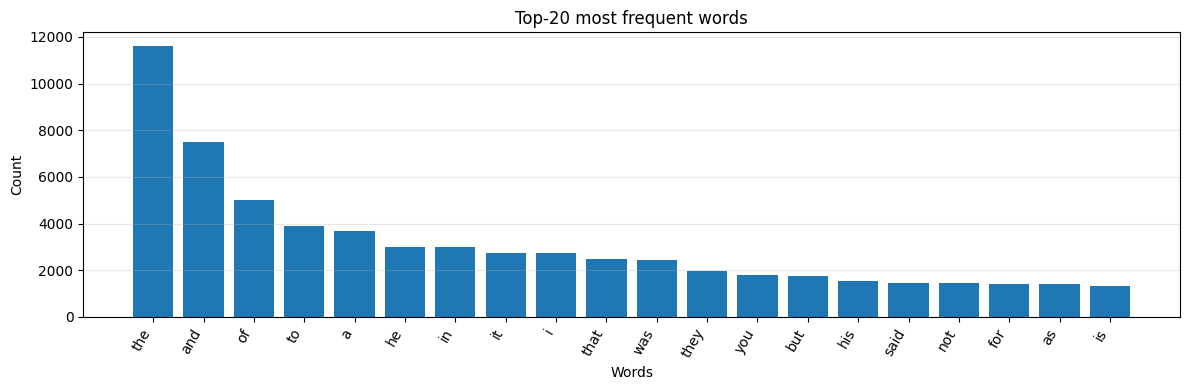

In [15]:
TOPN = min(20, len(counter))
top = counter.most_common(TOPN)

words = [w for w, _ in top]
counts = [c for _, c in top]

plt.figure(figsize=(12, 4))
plt.bar(words, counts)
plt.xticks(rotation=60, ha="right")
plt.title(f"Top-{TOPN} most frequent words")
plt.xlabel("Words")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Задание 5
Подготовка данных для CBOW

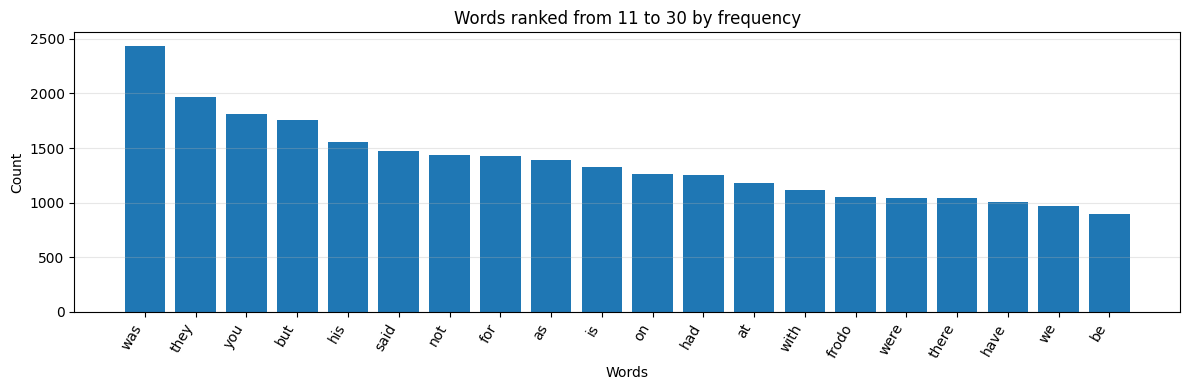

In [16]:
left = 10
right = min(30, len(counter))

part = counter.most_common(right)[left:right]

words = [w for w, _ in part]
counts = [c for _, c in part]

plt.figure(figsize=(12, 4))
plt.bar(words, counts)
plt.xticks(rotation=60, ha="right")
plt.title(f"Words ranked from {left + 1} to {right} by frequency")
plt.xlabel("Words")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Обучение CBOW модели

Визуализация 10–30 самых частых слов